In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, Ball2Stick2Zeppelin2Dti
from flax import nnx


ball_stick = Ball2Stick2Zeppelin2Dti.from_theta(np.random.randn(Ball2Stick2Zeppelin2Dti.theta_dim))

ImportError: cannot import name 'HighGaussianNoise' from 'dmri.simulators.noise_compartments' (/weka/macke/mgloeckler90/simformer_model_selection/dmri/dmri/simulators/noise_compartments.py)

In [3]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4 = jax.random.split(rng, 5)
    bvals = jax.random.choice(rng0, jnp.array(list(range(0, 2100, 100))), shape=(100,))
    bvals = jnp.sort(bvals)
    bvecs = jax.random.normal(rng3, shape=(100, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    theta = jax.random.normal(rng1, shape=(Ball2Stick2Zeppelin2Dti.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.6, shape=(Ball2Stick2Zeppelin2Dti.fraction_prior.shape[0],))
    #model_mask = jnp.array([True, True, True])
    ball_stick = Ball2Stick2Zeppelin2Dti.from_theta(theta, model_mask=model_mask)
    
    x_o = ball_stick.signal(bvals, bvecs)
    x_o = x_o + jax.random.normal(rng4, shape=x_o.shape) * 0.01
    return model_mask, theta, x_o, bvals, bvecs
    
    

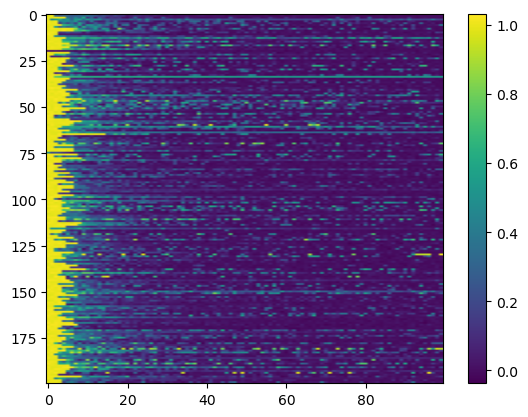

In [4]:
masks, theta, x_o, bvals, bvecs = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto')
plt.colorbar()

In [5]:
masks.shape, theta.shape, x_o.shape, bvals.shape, bvecs.shape

((200, 7), (200, 33), (200, 100), (200, 100), (200, 100, 3))

In [6]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig
    
cfg = DMRIInferenceModelConfig(Ball2Stick2Zeppelin2Dti)

model = DMRIInferenceModel(cfg, nnx.Rngs(0))

params_encoder = nnx.state(model.encoder)
params_model_decoder = nnx.state(model.model_decoder)
params_inference_decoder = nnx.state(model.inference_decoder)

params = (params_encoder, params_model_decoder, params_inference_decoder)


In [7]:
nnx.display(model)

In [8]:
import optax


optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.adamw(5e-4))

opt_state = optimizer.init(params)


In [9]:

def loss_fn(params, data, rng):
    components, thetas,  xs, bvals, bvecs = data
    
    return model._loss(params[0], params[1], params[2], components, thetas, bvals, bvecs, xs, rng)


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [10]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [11]:
key = jax.random.PRNGKey(4)
for i in range(200):
    key, subkey1 = jax.random.split(key, 2) 
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(subkey1, 2**18))
    l = 0
    for j in range(1000):
        key, subkey2 = jax.random.split(key, 2) 
        idx = jax.random.randint(subkey2, (256,), 0, 2**18)
        masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = masks[idx], thetas[idx], x_os[idx], bvals[idx], bevecs[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/10000) 

1.028191
0.9804736
0.9624186
0.9465945
0.93529457
0.9286558
0.9218459
0.9162045
0.9114889
0.90657747
0.9039162
0.8998386
0.89666224
0.8949531
0.8926679
0.8907002
0.88912493
0.88804436
0.8862521
0.8849


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x155551a21650>>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/dipy/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


0.8831977
0.88265514
0.88082093
0.880049
0.8786074
0.87768364
0.8775602
0.87685794
0.8757278
0.87465197
0.8738063
0.87390834
0.87266624
0.87143344
0.8714449
0.87020385
0.86989623
0.86960846
0.8690892
0.8679809
0.8681507
0.866835
0.86609036
0.8656377
0.862001
0.8607131
0.85881686
0.85827553
0.85734653
0.8560106
0.8552389
0.8548741
0.85381263
0.8533271
0.8525156
0.85302055
0.8517835
0.85169816
0.85067475
0.8504602
0.8498498
0.8499018
0.8489861
0.84867096
0.8476192
0.84681946
0.8484409
0.8475012
0.8476097
0.8460554
0.8461225
0.8447929
0.84542835
0.8454732
0.8447558
0.8461032
0.8451819
0.8457434
0.8446684
0.8441271
0.8439985
0.8441184
0.84326273
0.84322095
0.8430101
0.8424562
0.8421959
0.8421274
0.8426898
0.8421526
0.84211665
0.8421462
0.84173656
0.8406269
0.8407776
0.84028864
0.8406717
0.8409284
0.8394319
0.83991253
0.84034073
0.8394174
0.83924836
0.83933765
0.83882517
0.8391393
0.8383354
0.83866
0.83789486
0.8383299
0.8381431
0.8380368
0.8373722
0.83736515
0.83767116
0.8365617
0.836847
0

In [12]:
nnx.update(model.encoder, params[0])
nnx.update(model.model_decoder, params[1])
nnx.update(model.inference_decoder, params[2])

In [13]:
import pickle

with open('params_large.pkl', 'wb') as f:
    pickle.dump(params, f)

In [14]:
# import pickle
# with open('params.pkl', 'rb') as f:
#     params = pickle.load(f)
#     nnx.update(model.encoder, params[0])
#     nnx.update(model.model_decoder, params[1])
#     nnx.update(model.inference_decoder, params[2])

In [34]:
masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [51]:
idx = 18

In [52]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 128), bvals[idx], bevecs[idx], x_os[idx])

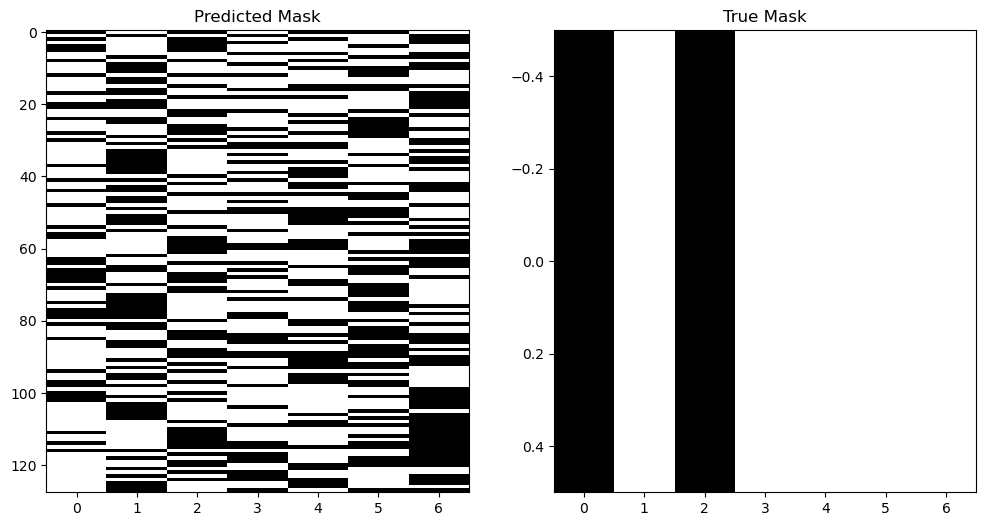

In [53]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')

plt.show()

In [54]:
from functools import partial

In [55]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=64, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 1024), bvals[idx], bevecs[idx], x_os[idx],masks[idx])

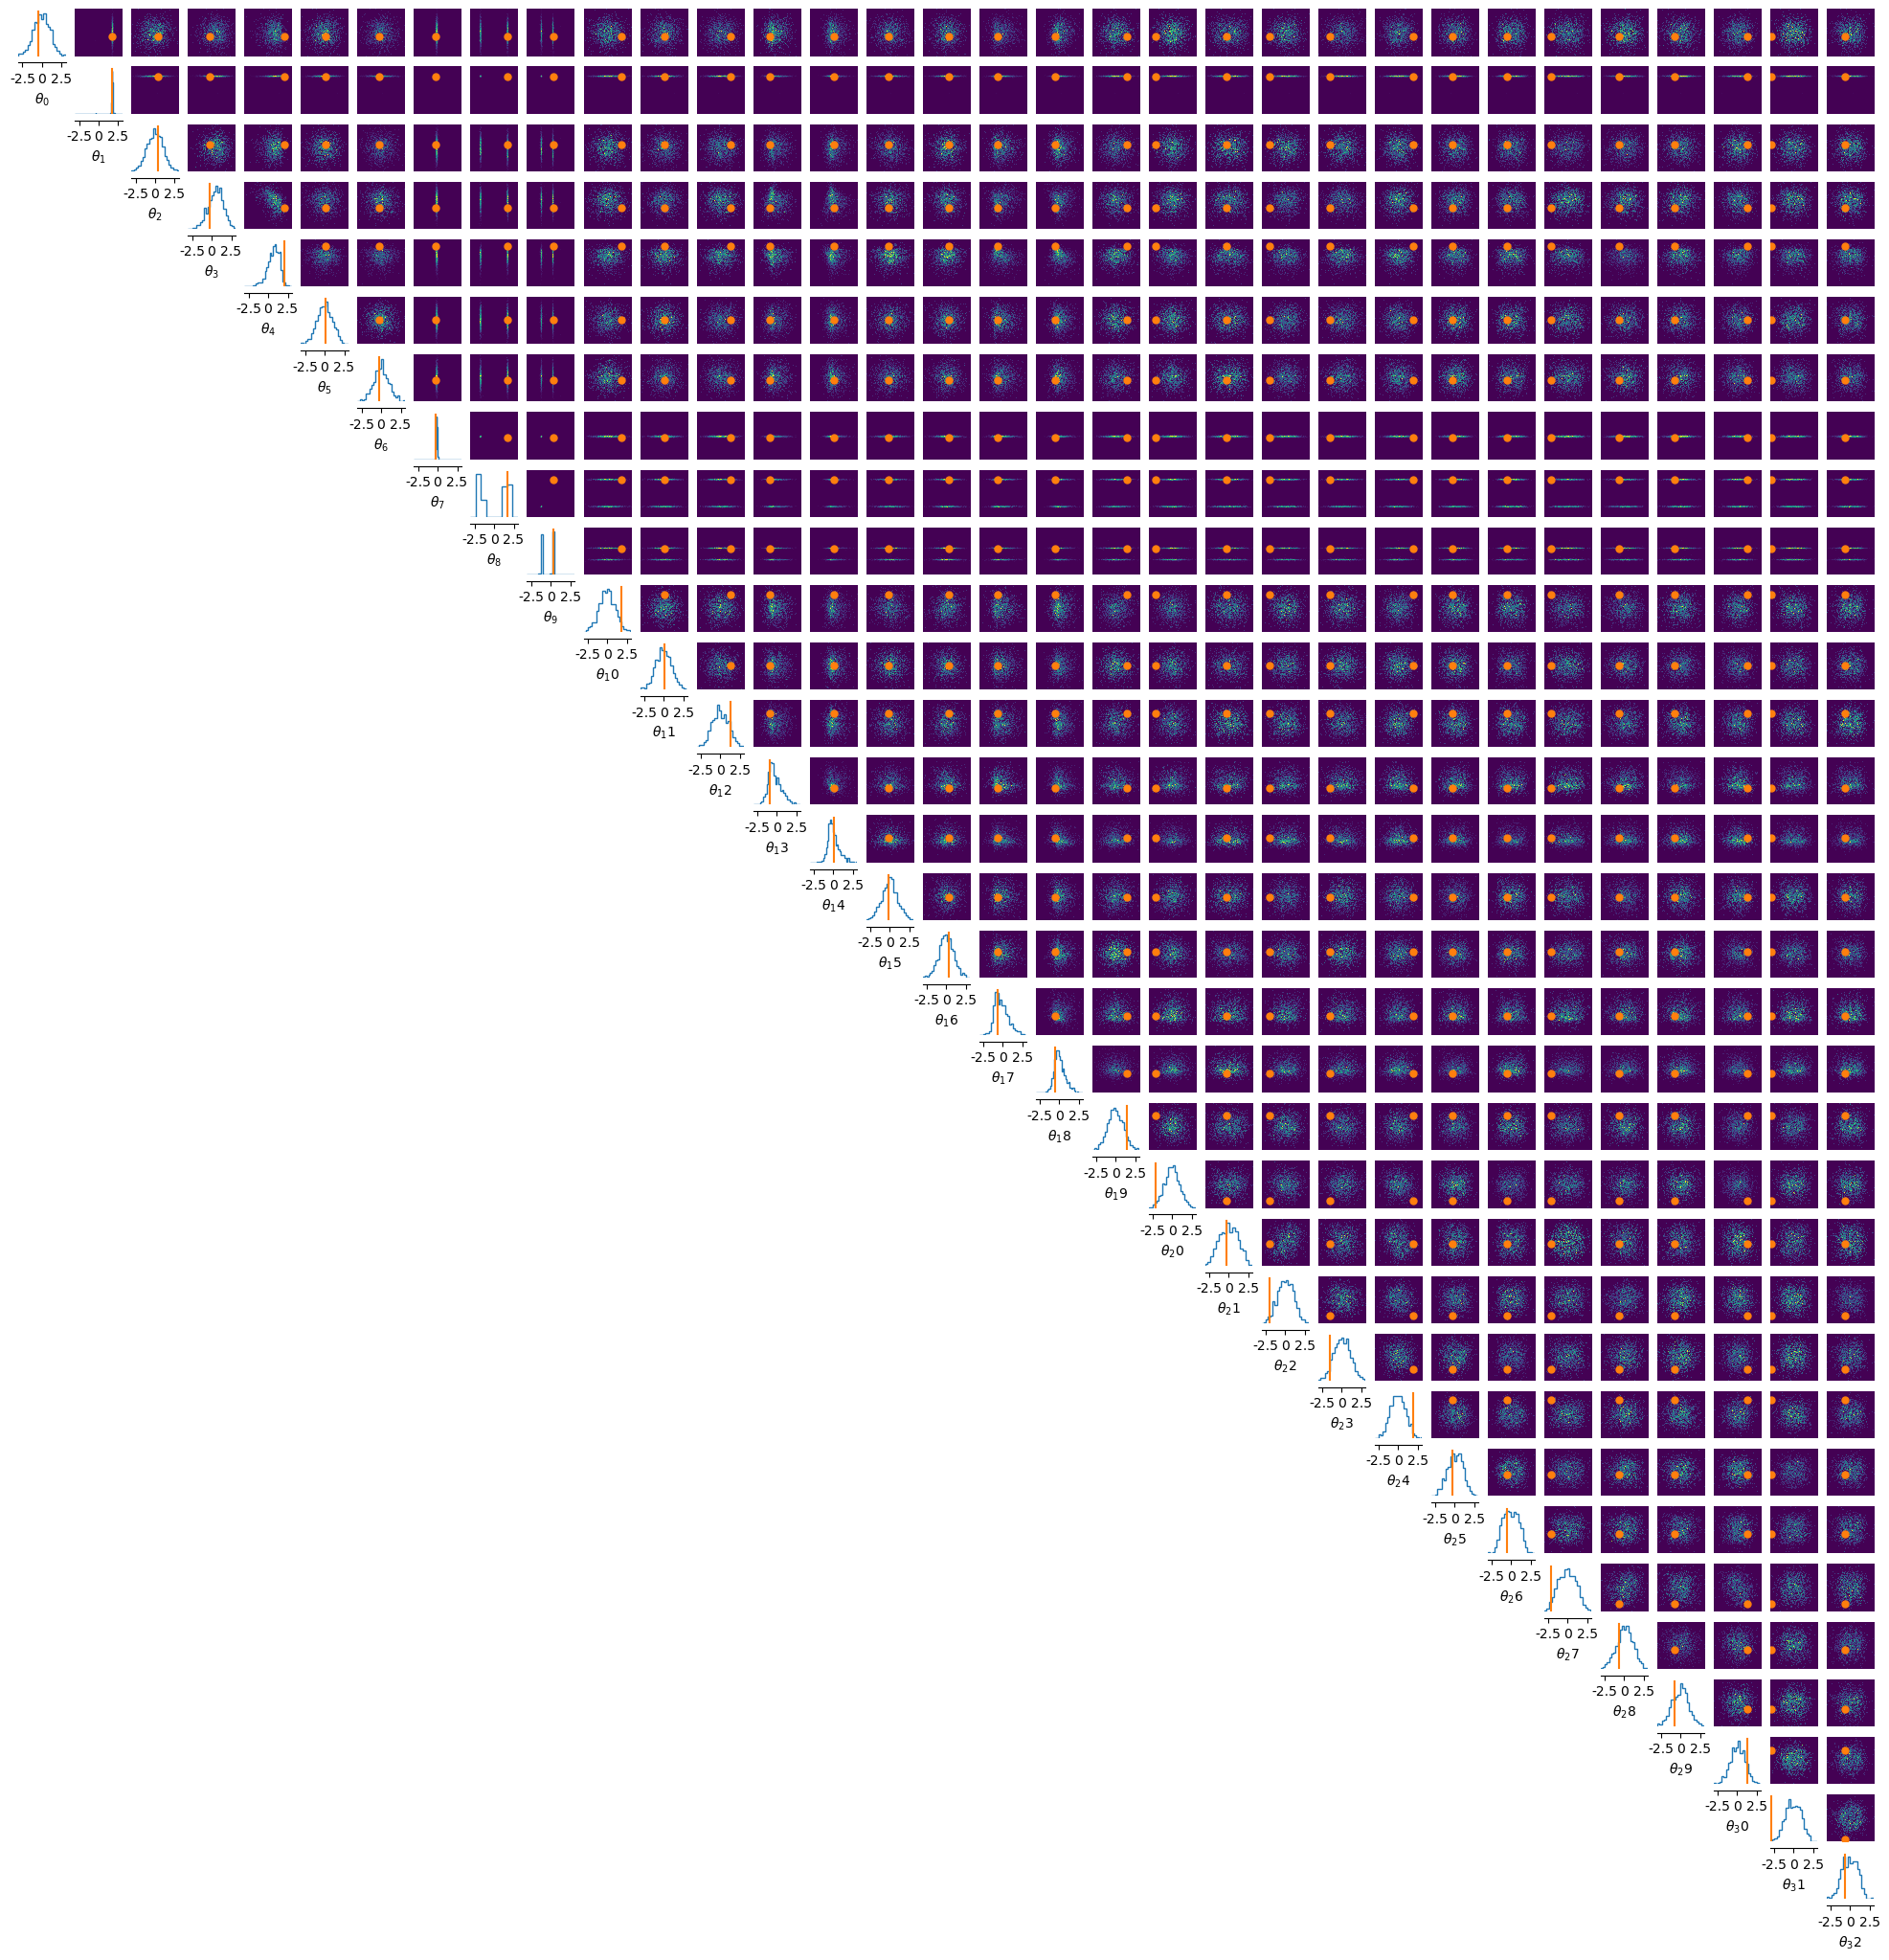

In [56]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [61]:
def posterior_pred(theta):
    return Ball2Stick2Zeppelin2Dti.from_theta(theta, model_mask=masks[idx]).signal(bvals[idx], bevecs[idx])

posterior_preds = jax.vmap(posterior_pred)(thetas_post)

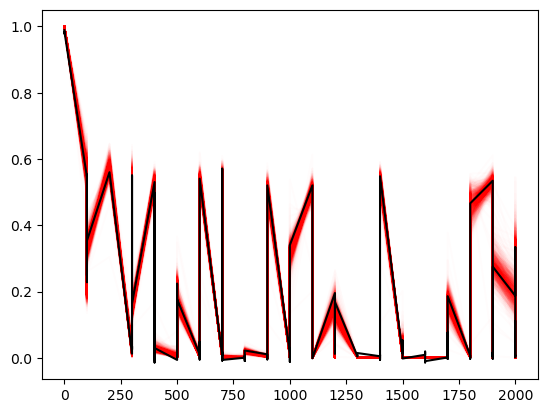

In [62]:
_ = plt.plot(bvals[idx], posterior_preds.T, label="posterior pred", color="red", alpha=0.01)
_ = plt.plot(bvals[idx], x_os[idx], label="data", color="black")